# Experiment 1: Data Pipeline & Preprocessing

**Student:** Yuvraj Gandhi &nbsp;|&nbsp; **Roll No:** 23101C0059 &nbsp;|&nbsp; **Branch:** INFT - C
**Subject:** Deep Learning Lab (PEIT37P) &nbsp;|&nbsp; **Dataset:** Titanic

**Aim:** Build a reusable data pipeline for the Titanic dataset covering cleaning, missing-value
handling, feature engineering, a stratified train/validation/test split, and a pipeline
implemented with reusable functions/classes.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)

NUMERIC_FEATURES = ["Age", "Fare", "FamilySize"]
CATEGORICAL_FEATURES = ["Sex", "Embarked", "Title", "Pclass", "IsAlone"]
FALLBACK_URL = (
    "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
)
COLUMN_ALIASES = {
    "survived": "Survived", "pclass": "Pclass", "name": "Name", "sex": "Sex",
    "age": "Age", "sibsp": "SibSp", "parch": "Parch", "ticket": "Ticket",
    "fare": "Fare", "cabin": "Cabin", "embarked": "Embarked", "passengerid": "PassengerId",
}

## Step 1 — Load Dataset

In [2]:
def _standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize column names to the Kaggle Titanic schema."""
    renamed = {
        column: COLUMN_ALIASES[column.lower()]
        for column in df.columns
        if column.lower() in COLUMN_ALIASES
    }
    return df.rename(columns=renamed)


def get_titanic_data(path: str = "../data/raw/titanic.csv") -> pd.DataFrame:
    """Load Titanic data from disk or fetch it from an available source."""
    data_path = Path(path)
    if data_path.exists():
        df = _standardize_columns(pd.read_csv(data_path))
        if "Name" in df.columns:
            return df

    data_path.parent.mkdir(parents=True, exist_ok=True)
    errors = []
    try:
        import seaborn as sns_data
        df = _standardize_columns(sns_data.load_dataset("titanic"))
        if "Name" in df.columns:
            df.to_csv(data_path, index=False)
            return df
        errors.append("seaborn dataset missing Name column")
    except Exception as exc:
        errors.append(f"seaborn.load_dataset failed: {exc}")

    try:
        df = _standardize_columns(pd.read_csv(FALLBACK_URL))
        df.to_csv(data_path, index=False)
        return df
    except Exception as exc:
        errors.append(f"URL download failed: {exc}")

    raise RuntimeError(
        "Could not obtain Titanic dataset automatically.\n"
        + "\n".join(f"- {m}" for m in errors)
    )


df = get_titanic_data()
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 2 — Check Missing Values

Cabin       687
Age         177
Embarked      2
dtype: int64


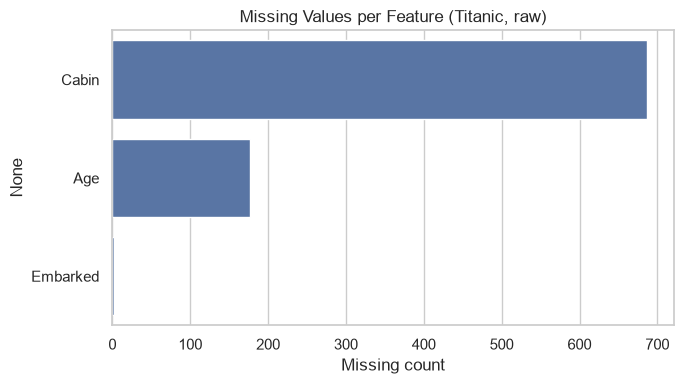

In [3]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)

plt.figure(figsize=(7, 4))
sns.barplot(x=missing.values, y=missing.index, color="#4C72B0")
plt.title("Missing Values per Feature (Titanic, raw)")
plt.xlabel("Missing count")
plt.tight_layout()
plt.savefig(FIGURES / "01_missing_values.png", dpi=150)
plt.show()

## Step 3 & 4 — Handle Missing Values and Feature Engineering

In [4]:
class TitanicPreprocessor:
    """End-to-end cleaning, feature engineering, and sklearn transformation."""

    def __init__(self):
        self.numeric_features = NUMERIC_FEATURES
        self.categorical_features = CATEGORICAL_FEATURES
        self.transformer = None
        self.preprocessor = None

    def extract_title(self, df: pd.DataFrame) -> pd.DataFrame:
        """Extract passenger title from Name before the column is dropped."""
        extracted = df.copy()
        extracted["Title"] = extracted["Name"].str.extract(r" ([A-Za-z]+)\.")
        return extracted

    def clean(self, df: pd.DataFrame) -> pd.DataFrame:
        """Drop unused columns and fill missing Embarked values."""
        cleaned = df.drop(columns=["Cabin", "Ticket", "Name", "PassengerId"], errors="ignore").copy()
        cleaned["Embarked"] = cleaned["Embarked"].fillna(cleaned["Embarked"].mode()[0])
        return cleaned

    def feature_engineer(self, df: pd.DataFrame) -> pd.DataFrame:
        """Add FamilySize and IsAlone features."""
        engineered = df.copy()
        engineered["FamilySize"] = engineered["SibSp"] + engineered["Parch"] + 1
        engineered["IsAlone"] = (engineered["FamilySize"] == 1).astype(int)
        return engineered

    def build_transformer(self) -> ColumnTransformer:
        """Build sklearn ColumnTransformer for numeric and categorical features."""
        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ])
        categorical_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ])
        return ColumnTransformer(transformers=[
            ("num", numeric_pipeline, self.numeric_features),
            ("cat", categorical_pipeline, self.categorical_features),
        ])

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """Fit the transformer on df and return transformed features."""
        self.transformer = self.build_transformer()
        self.preprocessor = self.transformer
        feature_frame = df[self.numeric_features + self.categorical_features]
        transformed = self.transformer.fit_transform(feature_frame)
        return pd.DataFrame(transformed)

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """Transform df using a fitted transformer."""
        if self.transformer is None:
            raise RuntimeError("Transformer is not fitted. Call fit_transform first.")
        feature_frame = df[self.numeric_features + self.categorical_features]
        transformed = self.transformer.transform(feature_frame)
        return pd.DataFrame(transformed)


pre = TitanicPreprocessor()
df = pre.extract_title(df)
print(df["Title"].value_counts())

df = pre.clean(df)
df = pre.feature_engineer(df)
df[["FamilySize", "IsAlone", "Title"]].head()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


,FamilySize,IsAlone,Title
0,2,0,Mr
1,2,0,Mrs
2,1,1,Miss
3,2,0,Mrs
4,1,1,Mr


### Visualize engineered features vs. survival

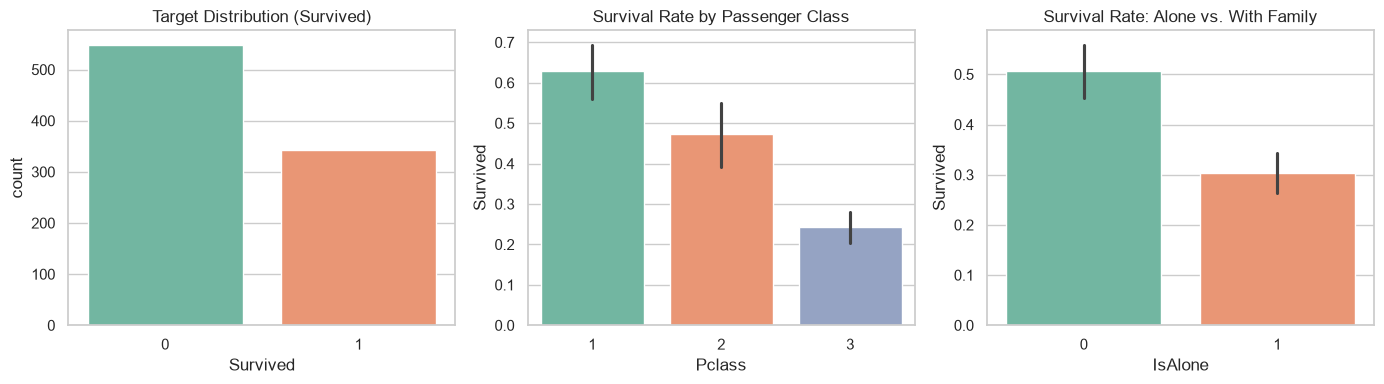

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=df, x="Survived", ax=axes[0], hue="Survived", palette="Set2", legend=False)
axes[0].set_title("Target Distribution (Survived)")

sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1], hue="Pclass", palette="Set2", legend=False)
axes[1].set_title("Survival Rate by Passenger Class")

sns.barplot(data=df, x="IsAlone", y="Survived", ax=axes[2], hue="IsAlone", palette="Set2", legend=False)
axes[2].set_title("Survival Rate: Alone vs. With Family")

plt.tight_layout()
plt.savefig(FIGURES / "02_engineered_features.png", dpi=150)
plt.show()

## Step 6 — Train / Validation / Test Split

train         623
validation    134
test          134
dtype: int64


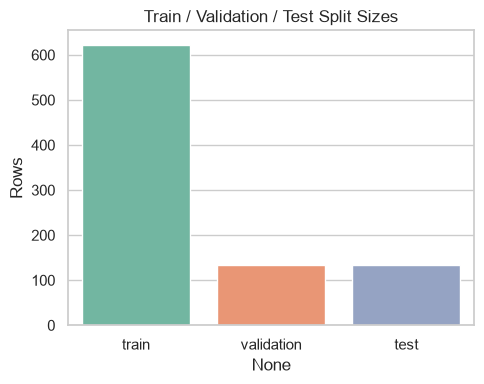

In [6]:
def split_data(df: pd.DataFrame, target_col: str = "Survived"):
    """Split data into stratified 70/15/15 train/val/test sets."""
    features = df.drop(columns=[target_col])
    target = df[target_col]

    x_train, x_temp, y_train, y_temp = train_test_split(
        features, target, test_size=0.30, stratify=target, random_state=42,
    )
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42,
    )

    train_df = x_train.copy(); train_df[target_col] = y_train
    val_df = x_val.copy(); val_df[target_col] = y_val
    test_df = x_test.copy(); test_df[target_col] = y_test
    return train_df, val_df, test_df


train_df, val_df, test_df = split_data(df)
split_sizes = pd.Series({"train": len(train_df), "validation": len(val_df), "test": len(test_df)})
print(split_sizes)

plt.figure(figsize=(5, 4))
sns.barplot(x=split_sizes.index, y=split_sizes.values, hue=split_sizes.index, palette="Set2", legend=False)
plt.title("Train / Validation / Test Split Sizes")
plt.ylabel("Rows")
plt.tight_layout()
plt.savefig(FIGURES / "03_split_sizes.png", dpi=150)
plt.show()

## Step 7 & 8 — Fit Reusable Pipeline and Save Processed Dataset

In [7]:
x_train = pre.fit_transform(train_df)
x_val = pre.transform(val_df)
x_test = pre.transform(test_df)

Path("../models").mkdir(exist_ok=True)
joblib.dump(pre.preprocessor, "../models/titanic_preprocessing_pipeline.pkl")
print("Pipeline saved to models/titanic_preprocessing_pipeline.pkl")

Path("../data/processed").mkdir(parents=True, exist_ok=True)
train_df.to_csv("../data/processed/train.csv", index=False)
val_df.to_csv("../data/processed/val.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

print("Train shape:", x_train.shape)
print("Validation shape:", x_val.shape)
print("Test shape:", x_test.shape)

Pipeline saved to models/titanic_preprocessing_pipeline.pkl
Train shape: (623, 26)
Validation shape: (134, 26)
Test shape: (134, 26)


## Conclusion

A reusable preprocessing pipeline was successfully developed for the Titanic dataset. Missing
values in `Age`, `Embarked`, and `Cabin` were handled through imputation and column removal.
Meaningful features — `FamilySize`, `IsAlone`, and `Title` — were engineered to improve
downstream model performance. Categorical variables were encoded using one-hot encoding, and
the dataset was split into training, validation, and testing subsets in a stratified manner
(70/15/15). The fitted `ColumnTransformer` pipeline was serialized with `joblib` for reuse in
production, and the project was organized using an industry-standard, Git-tracked structure.